In [8]:
import torch
import torch.nn as nn
import torchmetrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = "cuda"
torch.manual_seed(42)

In [9]:
from pathlib import Path
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

In [10]:
path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [11]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


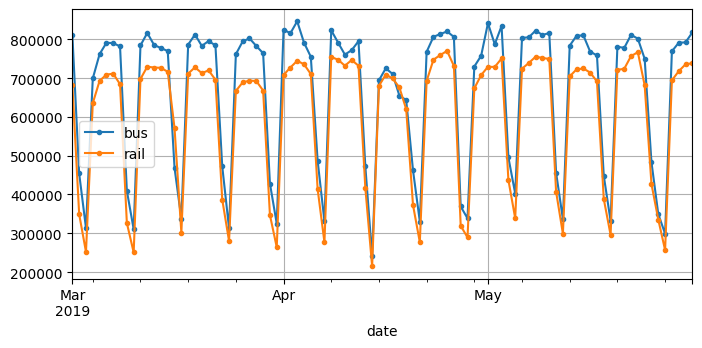

In [12]:
df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

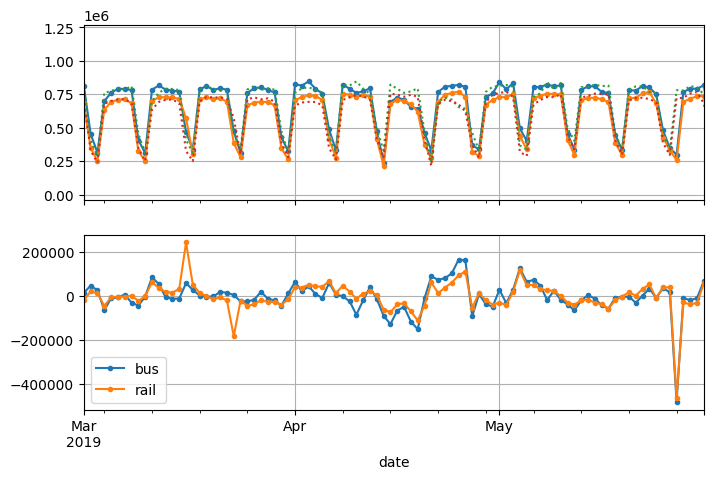

In [ ]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")
diff_7.plot(ax=axs[1], grid=True, marker=".")
plt.show()

In [18]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7/targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

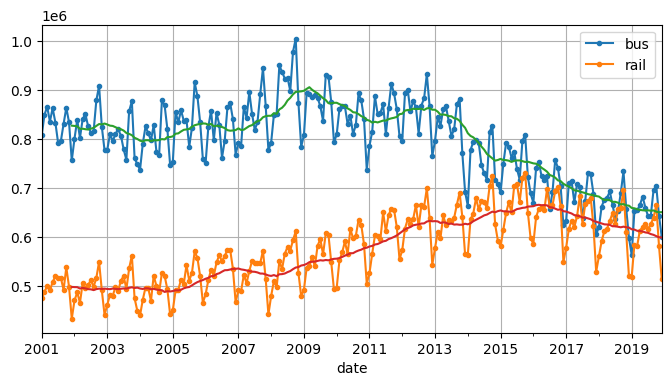

In [25]:
period = slice("2001","2019")
df_monthly = df.select_dtypes(include="number").resample('ME').mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8,4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
plt.show()

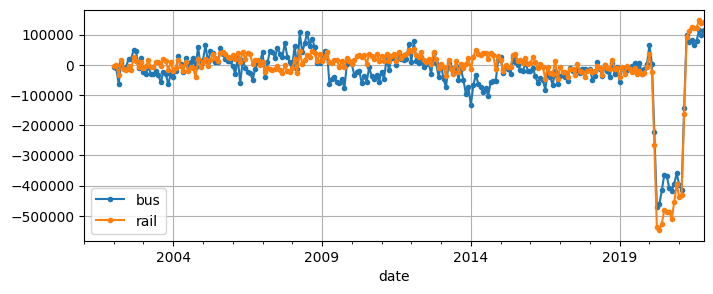

In [26]:
df_monthly.diff(12).plot(grid=True, marker='.', figsize=(8,3))
plt.show()

In [28]:
from torch.utils.data import DataLoader


class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series:torch.Tensor, window_length:int):
        self.series = series
        self.window_length = window_length
    
    def __len__(self):
        return len(self.series) - self.window_length
    
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length
        window = self.series[idx:end]
        target = self.series[end]
        return window, target
    
torch.manual_seed(0)

In [31]:
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)

window_length = 56
train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

In [ ]:

torch.manual_seed(42)
model = nn.Sequential(nn.Flatten(), nn.Linear(window_length, 1)).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

In [36]:
def train(model:nn.Module, loss_fn:nn.Module, optimizer:torch.optim.Optimizer, metric, dataloader:DataLoader, epoch:int = 1):
    model.train()
    optimizer.zero_grad()
    total_loss:float = 0
    for i in range(epoch):
        for idx, (X,y) in enumerate(dataloader):
            X,y = X.to(device), y.to(device)
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            print(f"epoch: {i} batch {idx} loss:{loss.item()}")
            total_loss += loss.item()

def test(model:nn.Module, loss_fn:nn.Module,dataloader:DataLoader):
    model.eval()
    
    total_loss = 0
    
    with torch.no_grad():
        for idx, (X,y) in enumerate(dataloader):
            X,y = X.to(device), y.to(device)
            y_pred = model(X)
            loss = loss_fn(y_pred,y)
            total_loss += loss.item()
    
    print(f"avg loss: {total_loss/len(dataloader)}")

In [34]:
train(model, loss_fn, optimizer, metric, train_loader)

epoch: 0 batch 0 loss:0.02485119178891182
epoch: 0 batch 1 loss:0.01707213930785656
epoch: 0 batch 2 loss:0.01947757415473461
epoch: 0 batch 3 loss:0.01397241372615099
epoch: 0 batch 4 loss:0.014275278896093369
epoch: 0 batch 5 loss:0.013677473179996014
epoch: 0 batch 6 loss:0.017784694209694862
epoch: 0 batch 7 loss:0.025388328358530998
epoch: 0 batch 8 loss:0.01786128804087639
epoch: 0 batch 9 loss:0.007208152674138546
epoch: 0 batch 10 loss:0.018055377528071404
epoch: 0 batch 11 loss:0.01701354794204235
epoch: 0 batch 12 loss:0.026673423126339912
epoch: 0 batch 13 loss:0.020926624536514282
epoch: 0 batch 14 loss:0.015167327597737312
epoch: 0 batch 15 loss:0.011639736592769623
epoch: 0 batch 16 loss:0.018856016919016838
epoch: 0 batch 17 loss:0.015179378911852837
epoch: 0 batch 18 loss:0.021589752286672592
epoch: 0 batch 19 loss:0.010036293417215347
epoch: 0 batch 20 loss:0.01296184677630663
epoch: 0 batch 21 loss:0.017406493425369263
epoch: 0 batch 22 loss:0.009566735476255417
epoch

In [38]:
test(model, loss_fn, valid_loader)

avg loss: 0.011025629937648773


In [ ]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(
            nn.Linear(input_size + hidden_size, hidden_size),
            nn.Tanh()
        )
        self.output = nn.Linear(hidden_size, output_size)
    
    def forward(self, X:torch.Tensor):
        batch_size, window_length, dimenshionality = X.shape
        X_time_first = X.transpose(0,1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H = self.memory_cell(XH)
        return self.output(H)

In [ ]:
class SimpleRnnModelV2(nn.Module):
    def __init__(self, input_size:int, hidden_size:int, output_size:int):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)
    
    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

In [ ]:
class LstmModel(nn.Module):
    def __init__(self, input_size:int, hidden_size:int, output_size:int):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.LSTMCell(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
    
    def forward(self, X:torch.Tensor):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0,1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        C = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            H, C = self.memory_cell(X_t, (H,C))
        return self.output(H)